In [1]:
import scanpy as sc

In [2]:
import pandas as pd

data = pd.read_csv(
    "GSE67602_Joost_et_al_expression.txt",
    sep="\t",
    index_col=0
)

data = data.T
print(data.shape)

(1422, 26024)


In [3]:
data.head()

Gene\Cell,ERCC-00002,ERCC-00003,ERCC-00004,ERCC-00009,ERCC-00012,ERCC-00013,ERCC-00014,ERCC-00016,ERCC-00017,ERCC-00019,...,r_MARINER1_EC,r_HERVL32-int,r_Tigger1a_Mars,r_(CATCG)n,r_(CGTTG)n,r_MurSAT1,r_HY5,r_tRNA-Arg-CGA_,r_U14,r_(CGTAG)n
1772067055_A01,363,20,276,25,0,1,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
1772067055_A03,330,17,258,14,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1772067055_A04,267,14,215,14,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
1772067055_A05,262,16,190,7,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1772067055_A06,334,20,244,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
adata = sc.AnnData(data)

In [5]:
adata

AnnData object with n_obs × n_vars = 1422 × 26024

In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata)

sc.tl.pca(adata)

C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [7]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
adata

AnnData object with n_obs × n_vars = 1421 × 4666
    obs: 'n_genes'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [9]:
adata.var['n_cells']

Gene\Cell
ERCC-00039         221
ERCC-00097          86
ERCC-00109          65
ERCC-00117          21
ERCC-00123          16
                  ... 
r_(AGTAG)n          22
r_tRNA-Met-i        54
r_tRNA-His-CAY_    233
r_MurSAT1           86
r_U14               95
Name: n_cells, Length: 4666, dtype: int32

In [10]:
import pandas as pd

# Convert to DataFrame for GRNBoost2
expr_matrix = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=adata.var_names
)

print(expr_matrix.shape)  # (1421, ~2993)

# Save as checkpoint
expr_matrix.to_csv("expression_matrix.tsv", sep="\t")

(1421, 4666)


In [11]:
# Install correct dask version first
# pip install dask==2023.5.0 distributed==2023.5.0

import pandas as pd
from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2

# Load expression matrix
expr_matrix = pd.read_csv("expression_matrix.tsv", sep="\t", index_col=0)

# Load mouse TF list
tf_names = load_tf_names("mm_mgi_tfs.txt")
print(f"Total TFs: {len(tf_names)}")  # 1721

# Filter to only TFs present in expression matrix
valid_tfs = list(set(tf_names) & set(expr_matrix.columns))
print(f"Valid TFs in data: {len(valid_tfs)}")  # 235

# Run GRNBoost2
network = grnboost2(
    expression_data=expr_matrix,
    tf_names=valid_tfs,
    verbose=True
)

# Save network
network.to_csv("adjacencies.tsv", sep="\t", index=False)
print(network.head())

Total TFs: 1721
Valid TFs in data: 358
preparing dask client
parsing input
creating dask graph
4 partitions
computing dask graph
shutting down client and local cluster
finished
        TF  target  importance
154  Prdx5  Tspan8   14.985722
154  Prdx5  Fam25c   14.879215
313  Hmgb2   Birc5   14.087412
154  Prdx5   Calm5   12.659856
225  Runx3   Prkcb   12.395829


In [12]:
import pandas as pd
from pyscenic.utils import GeneSignature
from pyscenic.aucell import aucell

# Load adjacency network
adj = pd.read_csv("adjacencies.tsv", sep="\t")

# Build GeneSignature regulons
regulons = []
for tf, group in adj.groupby("TF"):
    genes = list(group["target"])
    regulons.append(
        GeneSignature(
            name=tf,
            gene2weight=dict.fromkeys(genes, 1.0)
        )
    )
print(f"Total regulons: {len(regulons)}")  # 235

# Load expression matrix
expr = pd.read_csv("expression_matrix.tsv", sep="\t", index_col=0)

# Run AUCell
auc_matrix = aucell(expr, regulons)
print(auc_matrix.shape)  # (1421, 235)

# Save results
auc_matrix.to_csv("regulon_activity.csv")

Total regulons: 358
(1421, 358)


C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


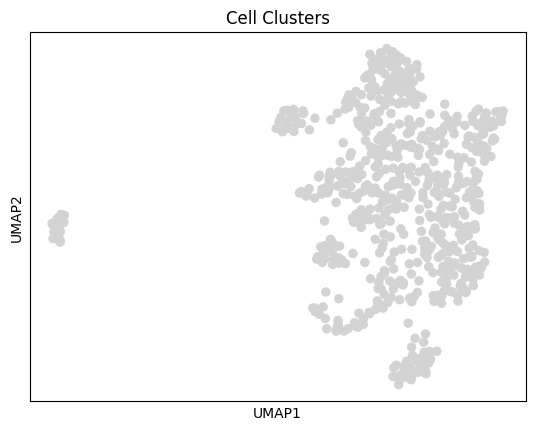

In [13]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load clean expression matrix
expr = pd.read_csv("expression_matrix.tsv", sep="\t", index_col=0)

# Create AnnData — transpose to cells x genes
adata_viz = sc.AnnData(expr)

# Remove zero-count cells
cell_sum = adata_viz.X.sum(axis=1)
adata_viz = adata_viz[cell_sum > 0].copy()

# Filter
sc.pp.filter_cells(adata_viz, min_counts=1)
sc.pp.filter_genes(adata_viz, min_cells=1)

# NOTE: Since expression_matrix.tsv is already normalized+log transformed,
# DO NOT normalize again. Directly run PCA.
sc.pp.pca(adata_viz)
sc.pp.neighbors(adata_viz)
sc.tl.umap(adata_viz)

# Plot UMAP
sc.pl.umap(adata_viz, title="Cell Clusters")

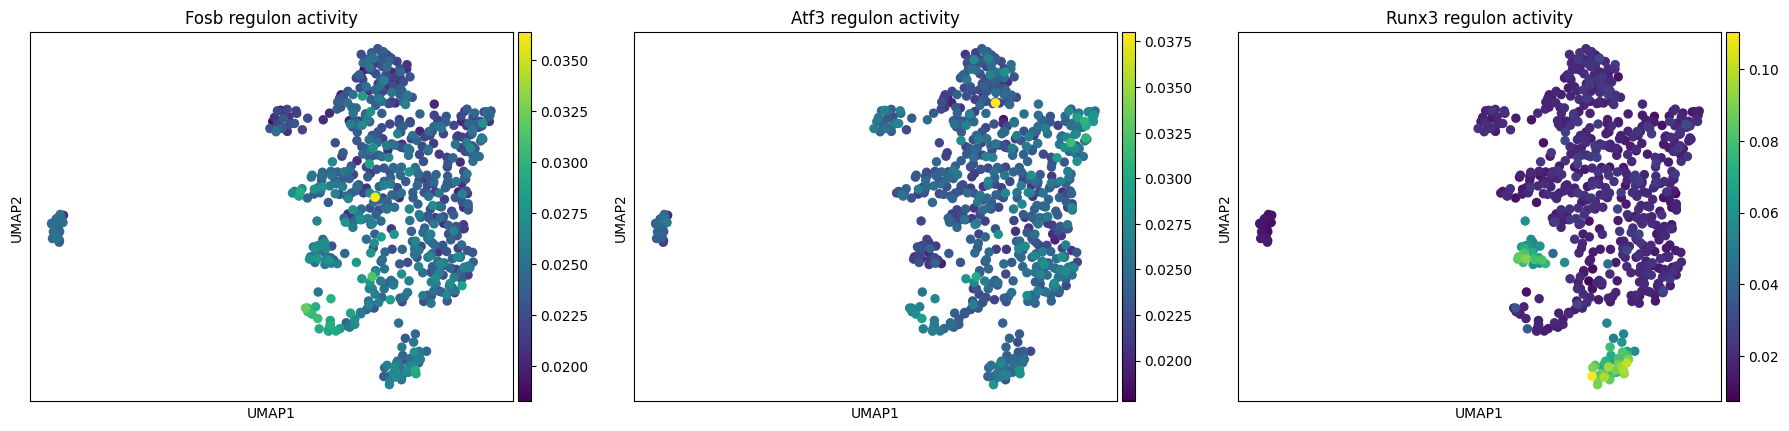

In [15]:
# Load AUCell results
auc_df = pd.read_csv("regulon_activity.csv", index_col=0)

# Rename columns to avoid conflict with gene names
# e.g., "Fosb" → "Fosb_regulon"
auc_df.columns = [f"{col}_regulon" for col in auc_df.columns]

# Add to AnnData obs
adata_viz.obs = adata_viz.obs.join(auc_df, how="left")

# Use renamed columns for visualization
top_tfs = ["Fosb_regulon", "Atf3_regulon", "Runx3_regulon"]

sc.pl.umap(
    adata_viz,
    color=top_tfs,
    title=[f"{tf.replace('_regulon', '')} regulon activity" for tf in top_tfs]
)

In [1]:
!pip install leidenalg

You should consider upgrading via the 'C:\Users\91756\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\91756\Ap

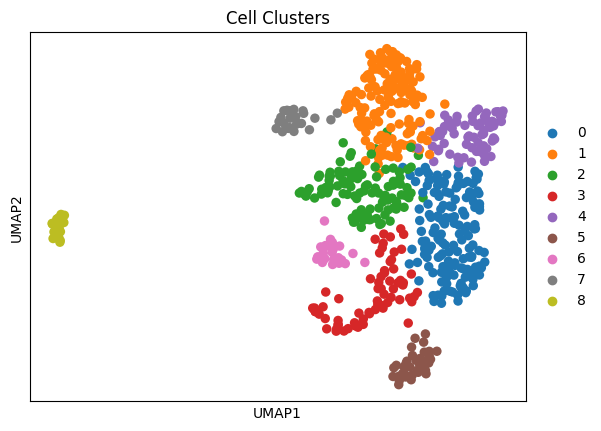

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load clean expression matrix
expr = pd.read_csv("expression_matrix.tsv", sep="\t", index_col=0)
expr = expr.replace([np.inf, -np.inf], np.nan)
expr = expr.fillna(0)
expr = expr.astype(float)

# Create AnnData
adata_viz = sc.AnnData(expr)

# Remove zero-count cells
cell_sum = adata_viz.X.sum(axis=1)
adata_viz = adata_viz[cell_sum > 0].copy()

# Filter
sc.pp.filter_cells(adata_viz, min_counts=1)
sc.pp.filter_genes(adata_viz, min_cells=1)

# PCA → Neighbors → UMAP
sc.pp.pca(adata_viz)
sc.pp.neighbors(adata_viz)
sc.tl.umap(adata_viz)

# Leiden Clustering
sc.tl.leiden(adata_viz, resolution=0.5)

# Plot
sc.pl.umap(adata_viz, color="leiden", title="Cell Clusters")

C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\91756\AppData\Local\Programs\Python\Python39\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid 

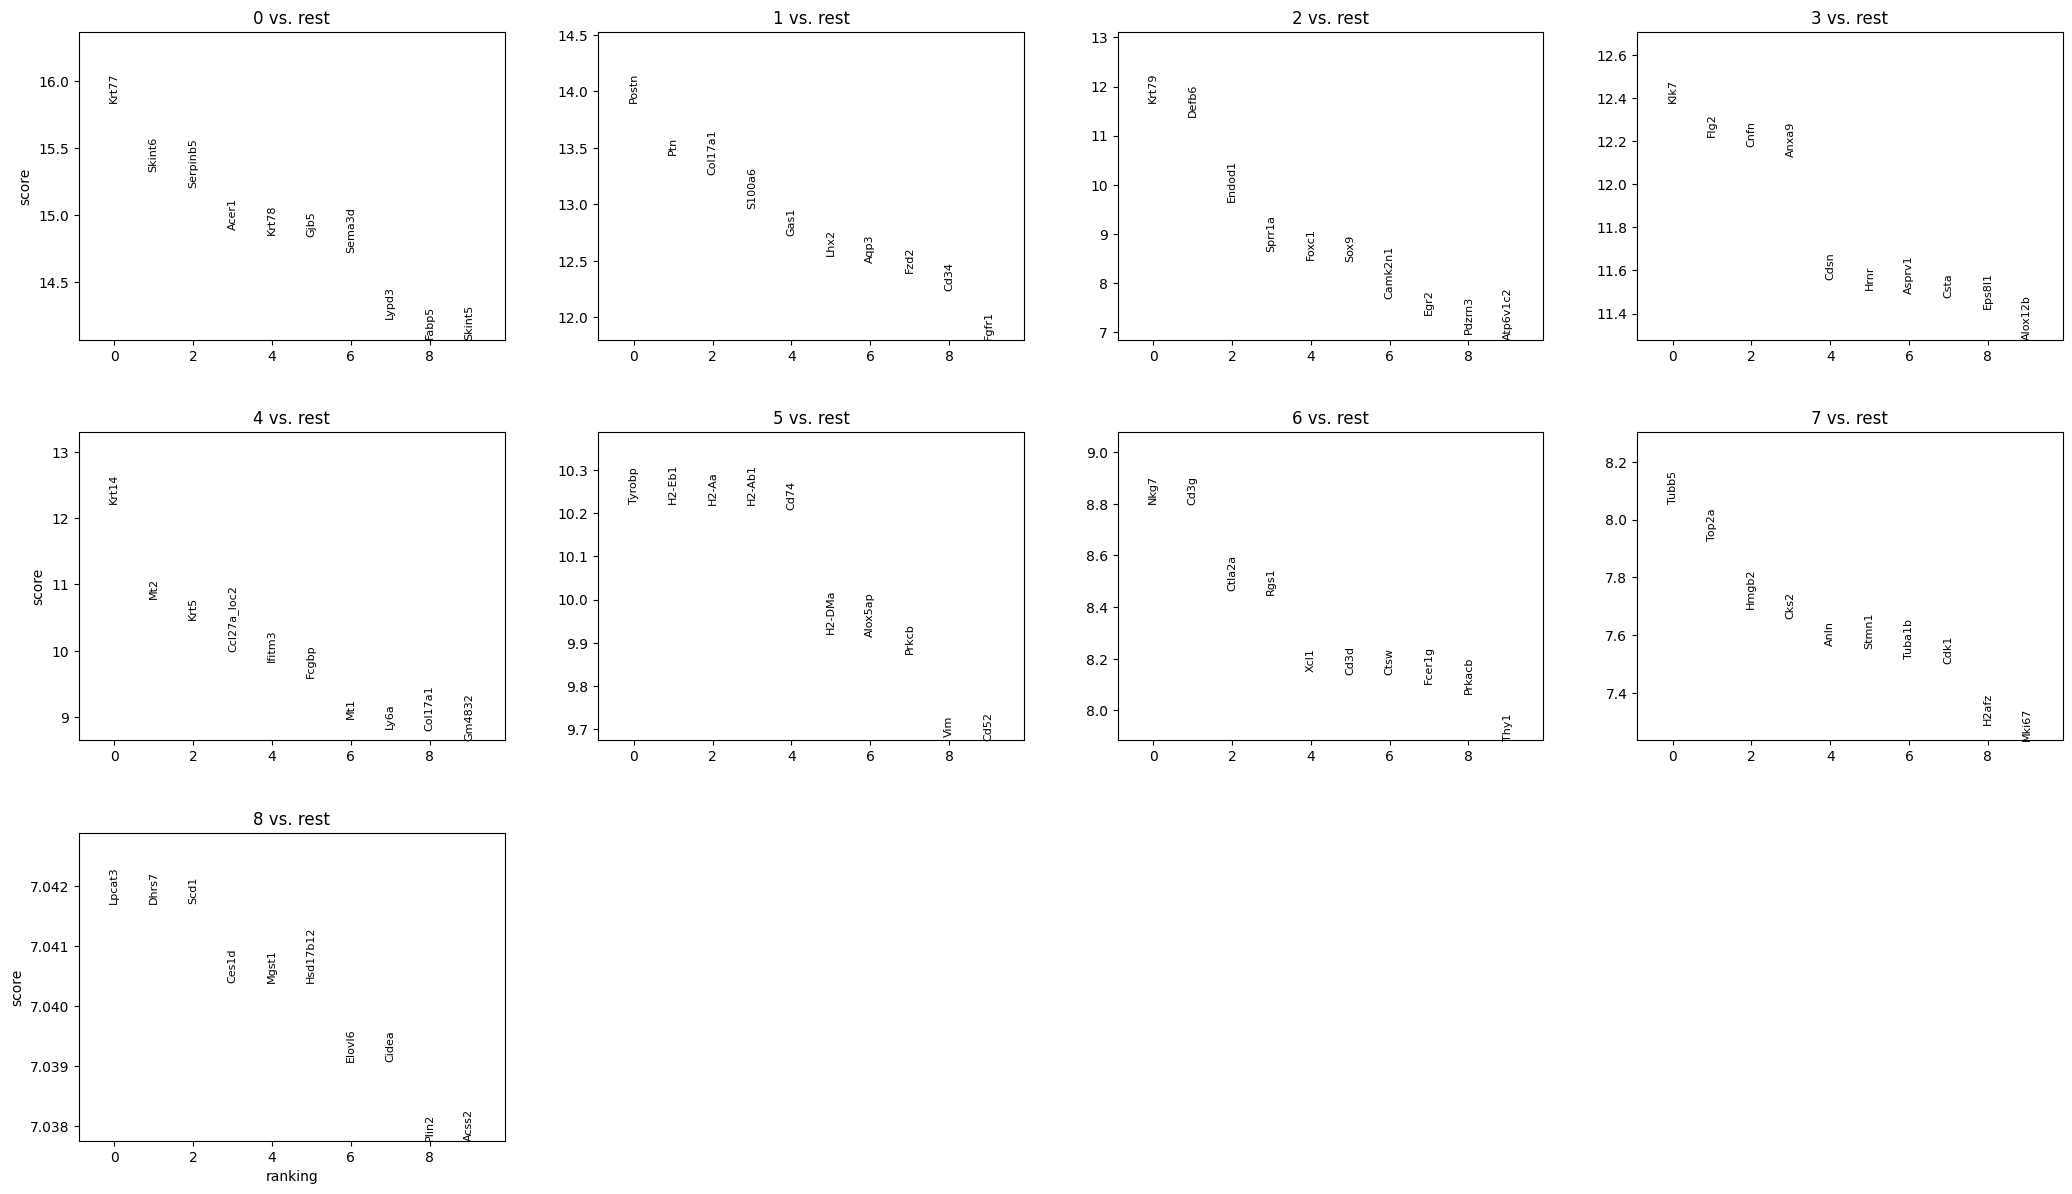

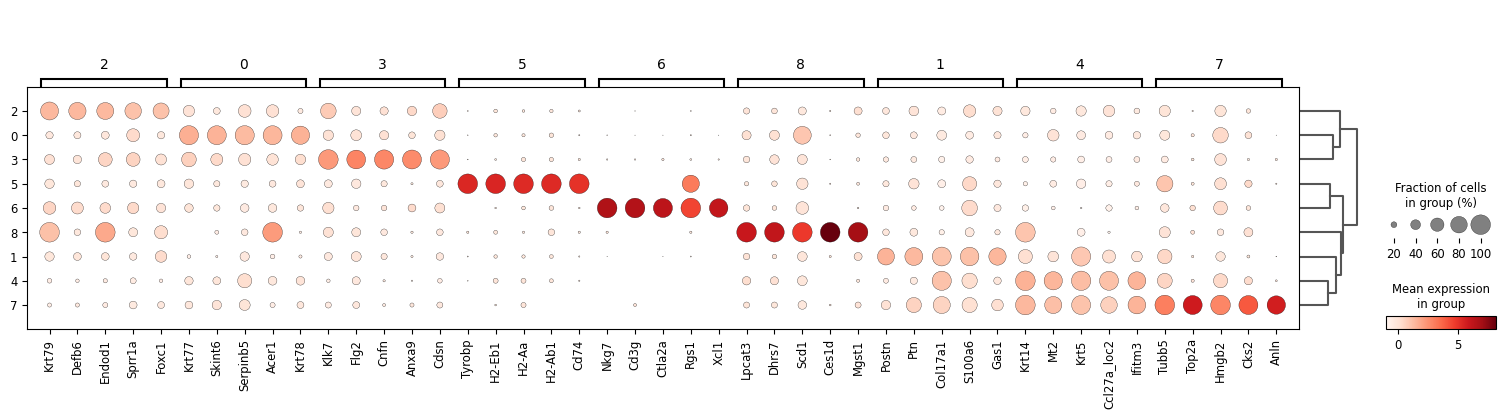

In [4]:
# Find genes that distinguish each cluster
sc.tl.rank_genes_groups(adata_viz, groupby="leiden", method="wilcoxon")

# Visualize top marker genes
sc.pl.rank_genes_groups(adata_viz, n_genes=10, sharey=False)

# As a dotplot
sc.pl.rank_genes_groups_dotplot(adata_viz, n_genes=5)

In [8]:
import pandas as pd
import numpy as np

# Load AUCell matrix
auc_df = pd.read_csv("regulon_activity.csv", index_col=0)
auc_df.index = auc_df.index.str.strip()

# Get cluster labels from adata_viz
cluster_labels = adata_viz.obs[["leiden"]]

# Join by index
auc_df = auc_df.join(cluster_labels, how="inner")

print(f"Matched cells: {len(auc_df)}")

# Fix — use "leiden" instead of "cluster"
cluster_activity = auc_df.groupby("leiden").mean()

print(cluster_activity)

Matched cells: 648
        1810024B03Rik  2310011J03Rik  2610044O15Rik8  6720489N17Rik  AI987944  \
leiden                                                                          
0            0.028574       0.026790        0.023797       0.023417  0.023054   
1            0.024941       0.023868        0.025230       0.029642  0.023154   
2            0.024693       0.024911        0.025107       0.024251  0.023428   
3            0.020875       0.026145        0.030818       0.029023  0.019423   
4            0.030735       0.025214        0.027712       0.027769  0.023764   
5            0.014598       0.018959        0.022752       0.012161  0.023656   
6            0.018485       0.018489        0.020769       0.012891  0.041597   
7            0.019499       0.019173        0.020035       0.031448  0.027155   
8            0.016889       0.034439        0.013815       0.011306  0.032229   

          Acaa1b      Aco1    Adarb1      Adnp     Aggf1  ...      Zhx1  \
leiden        

C:\Users\91756\AppData\Local\Temp\ipykernel_31064\483614924.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_activity = auc_df.groupby("leiden").mean()


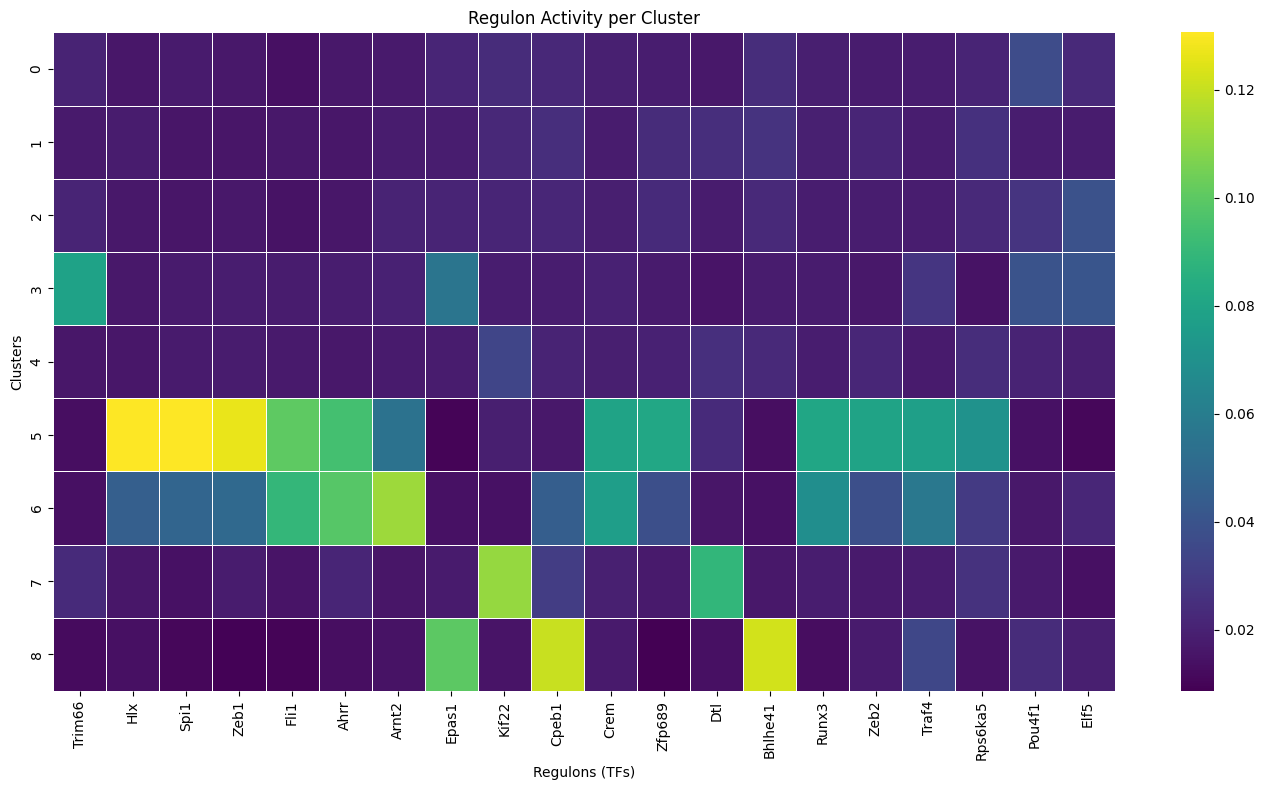

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fix — drop "leiden" instead of "cluster"
top_regulons = auc_df.drop(columns="leiden").var().nlargest(20).index.tolist()

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_activity[top_regulons],
    cmap="viridis",
    annot=False,
    linewidths=0.5
)
plt.title("Regulon Activity per Cluster")
plt.xlabel("Regulons (TFs)")
plt.ylabel("Clusters")
plt.tight_layout()
plt.savefig("regulon_heatmap.png", dpi=150)
plt.show()

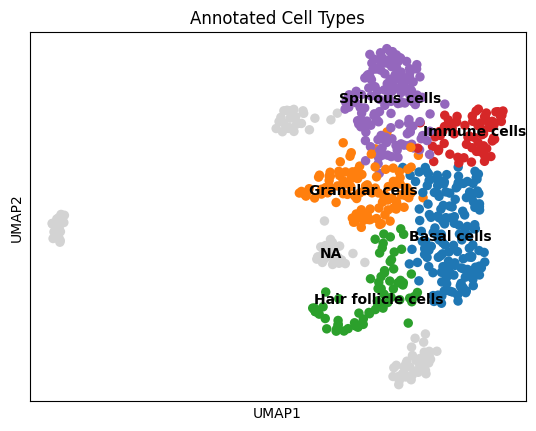

In [11]:
# After identifying clusters, manually assign cell type names
# based on marker genes and known biology

cell_type_map = {
    "0": "Basal cells",
    "1": "Spinous cells",
    "2": "Granular cells",
    "3": "Hair follicle cells",
    "4": "Immune cells",
    # add more based on your marker gene analysis
}

adata_viz.obs["cell_type"] = adata_viz.obs["leiden"].map(cell_type_map)

# Plot with cell type labels
sc.pl.umap(adata_viz, color="cell_type", title="Annotated Cell Types", legend_loc="on data")

In [13]:
import pandas as pd

# Load AUCell matrix
auc_df = pd.read_csv("regulon_activity.csv", index_col=0)
auc_df.index = auc_df.index.str.strip()

# Rename columns to avoid conflict with gene names
auc_df.columns = [f"{col}_regulon" for col in auc_df.columns]

# Add to adata_viz.obs by index
adata_viz.obs = adata_viz.obs.join(auc_df, how="left")

# Verify columns exist
print("Fosb_regulon" in adata_viz.obs.columns)   # should print True
print("Atf3_regulon" in adata_viz.obs.columns)   # should print True
print("Runx3_regulon" in adata_viz.obs.columns)  # should print True

True
True
True


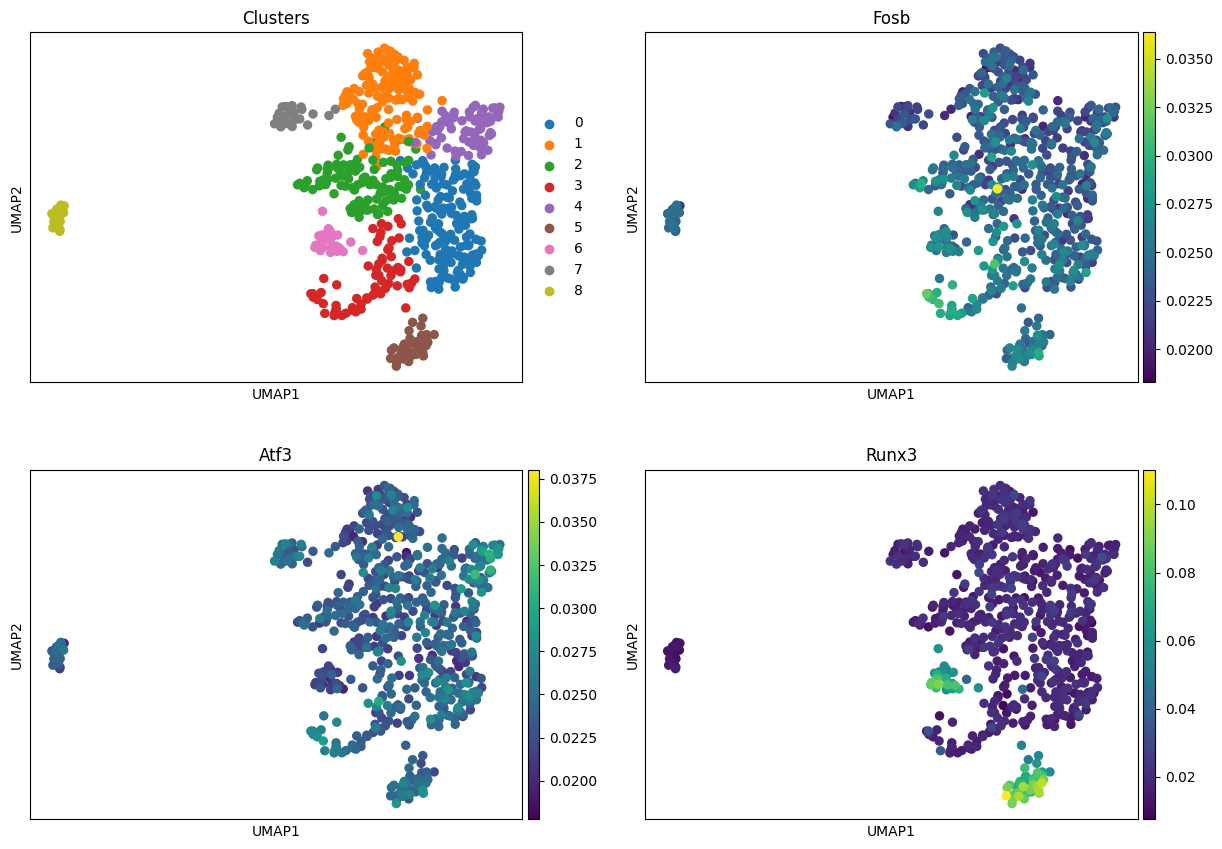

In [14]:
top_tfs = ["Fosb_regulon", "Atf3_regulon", "Runx3_regulon"]

sc.pl.umap(
    adata_viz,
    color=["leiden"] + top_tfs,
    ncols=2,
    title=["Clusters"] + [tf.replace("_regulon", "") for tf in top_tfs]
)

In [15]:
# Save the final AnnData object
adata_viz.write("final_adata.h5ad")

# Save cluster assignments with cell type
adata_viz.obs[["leiden", "cell_type"]].to_csv("cell_clusters.csv")

print("All results saved!")

All results saved!
